# Section 1 - Imports & Setup


### 1.1 - Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import random
import joblib
from sklearn.metrics import recall_score, precision_score, f1_score, roc_auc_score, average_precision_score


In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True


### 1.2 - Path Setup and Data Loading

In [3]:
import sys
from pathlib import Path

# Define the Root (at SCANIA COMPONENT X)
PROJECT_ROOT = Path.cwd().parent

# Data Directory (Matches your "Data/Processed Data" folder exactly)
DATA_DIR = PROJECT_ROOT / "Data" / "Processed Data"

# Results Hierarchy
RESULTS_DIR = PROJECT_ROOT / "Results"
MODEL_DIR = RESULTS_DIR / "Models"
PREDICTION_DIR = RESULTS_DIR / "Predictions"

# Adding root to sys.path for imports
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

# Diagnostic Prints
print(f"Project Root: {PROJECT_ROOT}")
print(f"Data Source:  {DATA_DIR}")
print(f"Model Path:   {MODEL_DIR}")
print(f"Predictions:  {PREDICTION_DIR}")

# Test if we can see the data file aka. if the path set-up is correct and the file exists
test_file = DATA_DIR / "val_processed.csv"
if test_file.exists():
    print(f"Success! Found {test_file}")
else:
    raise FileNotFoundError(f"Missing expected file: {test_file}")

Project Root: c:\Users\Elias\Documents\SCANIA Component X
Data Source:  c:\Users\Elias\Documents\SCANIA Component X\Data\Processed Data
Model Path:   c:\Users\Elias\Documents\SCANIA Component X\Results\Models
Predictions:  c:\Users\Elias\Documents\SCANIA Component X\Results\Predictions
Success! Found c:\Users\Elias\Documents\SCANIA Component X\Data\Processed Data\val_processed.csv


In [4]:
import importlib
import utils

importlib.reload(utils)

DEVICE = utils.DEVICE

if torch.cuda.is_available():
    print(f"Using CUDA at: {torch.cuda.get_device_name(0)}")
else:
    print("Warning. CUDA not avauilable. Using CPU, which may be slow for training.")

Using CUDA at: NVIDIA GeForce RTX 4060


### 1.3: Data Loading and Verification

In [5]:
# Importing the data files into pandas DataFrames. Skipping test_processed, as it will be used in the next notebook and not here.
train_data = pd.read_csv(DATA_DIR / 'train_processed.csv')
val_data   = pd.read_csv(DATA_DIR / 'val_processed.csv')

print("=== LOADED SUCCESSFULLY ===")
print(f"Training Data:   {train_data.shape}")
print(f"Validation Data: {val_data.shape}")


=== LOADED SUCCESSFULLY ===
Training Data:   (1122267, 213)
Validation Data: (196227, 213)


In [6]:
# Double checking the sizes of the loaded data and labels
print("=== Dataset Shapes ===")
print(f"Training Data: {train_data.shape}")
print(f"Validation Data: {val_data.shape}")
print('\n')

# Double cheking that no NaN values have snuck in
print("=== Checking for Missing values  ===")
print(f"Training Data: {train_data.isnull().sum().sum()}")
print(f"Validation Data: {val_data.isnull().sum().sum()}")
print('\n')

print("=== Label Distributions ===")
print(f"Train labels:\n{train_data['label'].value_counts()}")
print(f"Validation labels:\n{val_data['label'].value_counts()}")

train_data.head()


=== Dataset Shapes ===
Training Data: (1122267, 213)
Validation Data: (196227, 213)


=== Checking for Missing values  ===
Training Data: 0
Validation Data: 0


=== Label Distributions ===
Train labels:
label
0    1096527
1      25740
Name: count, dtype: int64
Validation labels:
label
0    191150
1      5077
Name: count, dtype: int64


,vehicle_id,time_step,label,171_0_delta,666_0_delta,427_0_delta,837_0_delta,167_0_delta,167_1_delta,167_2_delta,...,397_26_delta_z,397_27_delta_z,397_28_delta_z,397_29_delta_z,397_30_delta_z,397_31_delta_z,397_32_delta_z,397_33_delta_z,397_34_delta_z,397_35_delta_z
0,0,11.2,0,-0.849629,-0.749216,-0.885264,-0.605540,0.000000,-0.836789,-0.846661,...,-3.542344,-3.268095,-2.502729,-0.600356,-2.468069,-3.298275,-3.425877,-3.137163,-2.606453,-0.620815
1,0,11.4,0,-0.849629,-0.749216,-0.885264,-0.605540,0.076528,-0.215680,-0.846661,...,-3.266259,-2.907830,-2.502729,-0.600356,-2.468069,-3.298275,-3.157949,-3.137163,-2.606453,-0.620815
2,0,19.6,0,0.051073,0.058223,0.038719,-0.007914,0.000000,-0.836789,-0.846661,...,0.744046,0.995731,0.849439,1.253825,1.120602,0.844823,0.768402,0.851787,0.847368,-0.620815
3,0,20.2,0,-0.095038,-0.141034,-0.078776,-0.309542,0.000000,-0.836789,-0.846661,...,0.020322,0.030062,-0.091699,-0.600356,-0.679019,0.056738,-0.102702,-0.130775,-0.413161,0.168930
4,0,21.0,0,-0.154429,-0.195811,-0.119957,-0.119320,0.000000,-0.836789,-0.846661,...,-0.123022,0.167128,-0.470938,-0.600356,-2.082818,-0.363323,-0.126239,0.004735,-0.293204,0.168930


# Section 2 - Data Input Preparation



### 2.1 - Inspecting the Data on how to arrange the sequence inputs based on its shape

In [7]:
# Checking the statistics of the overall training data
seq_lengths = train_data.groupby('vehicle_id')['time_step'].count()
seq_lengths.describe()

count    23540.000000
mean        47.674894
std         27.403192
min          5.000000
25%         28.000000
50%         43.000000
75%         64.000000
max        303.000000
Name: time_step, dtype: float64

In [8]:
# Checking the statistics of the failed classes from the training data
failed_vehicles = train_data[train_data['label'] == 1]['vehicle_id'].unique()
seq_lengths[failed_vehicles].describe()

count    2262.00000
mean       46.71397
std        24.11327
min         5.00000
25%        29.00000
50%        43.00000
75%        60.75000
max       236.00000
Name: time_step, dtype: float64

The distribution of the failed classes and the overall data seems to follow the same distribution, which could also bee seen in the Data preparation Notebook dring the EDA. For us, this means that we can pick a sequence size that follows this distribution. Since the most recent readings are most informative for failure prediction, sequences longer than the N timesteps chosen will be truncated and keeping the m last entries. Sequences that are shorter will be padded with zeros at the begining of their sequence. The chosen length is initialized below.

In [9]:
SEQ_LEN = 30

### 2.2 - Generating the Input Data

In [10]:
# For the LR data
X_train_lr, y_train_lr = utils.prepare_lr_data(train_data, 'label')
X_val_lr, y_val_lr = utils.prepare_lr_data(val_data, 'label')

# For the sequential data
X_train_seq, y_train_seq, train_seq_ids = utils.generate_sequential_data(train_data, 'label', SEQ_LEN)
X_val_seq, y_val_seq, val_seq_ids = utils.generate_sequential_data(val_data, 'label', SEQ_LEN)

INPUT_SIZE = X_train_seq.shape[2]

In [11]:
# Printing Statistical information on the Sequential Data
print("=== Statistical Properites Seq Data ===")
print(f"Train mean: {X_train_seq.mean():.3f}, std: {X_train_seq.std():.3f}")
print(f"Val mean:   {X_val_seq.mean():.3f}, std: {X_val_seq.std():.3f}")

=== Statistical Properites Seq Data ===
Train mean: -0.005, std: 0.618
Val mean:   0.025, std: 0.589


# Section 3 - Model Training

## 3.1 - Logistic Regression

### 3.1.1 - Logistic Regression Functions

In [37]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import learning_curve


def train_lr_model(X, y):
  lr_model = LogisticRegression(
    penalty='elasticnet',      
    l1_ratio=0.5,              
    C=5.0, 
    solver='saga',             
    class_weight='balanced', 
    random_state=SEED, 
    max_iter=1000
)

  lr_model.fit(X, y)

  return lr_model

def get_lr_predictions(model, X):
  predictions = model.predict(X)
  probabilities = model.predict_proba(X)[:,1]

  return predictions, probabilities

def save_lr_predictions(X, predictions, probabilities, path):
  vehicle = X.index.values

  predictions_df = pd.DataFrame({
      'vehicle_id': vehicle,
      'probability': probabilities,
      'binary_prediction': predictions
  })

  print("Saving the DataFrame...")
  predictions_df.to_csv(path, index=False)
  print(f"DataFrame saved to {path}")

  return None

def save_lr_model(model, path):
  print("Saving the model...")
  joblib.dump(model, path)
  print(f"Model saved to {path}")

  return None


def plot_learning_curve(estimator, X, y):
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=5, scoring='f1', n_jobs=-1, 
        train_sizes=np.linspace(0.1, 1.0, 5)
    )
    
    train_scores_mean = np.mean(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    
    plt.figure(figsize=(8, 6))
    plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Training F1 Score")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="g", label="Cross-validation F1 Score")
    
    plt.title("Learning Curve")
    plt.xlabel("Training examples")
    plt.ylabel("F1 Score")
    plt.legend(loc="best")
    plt.grid()
    plt.show()


### 3.1.2 -  Training & Evaluation

In [38]:
# Train
lr_model = train_lr_model(X_train_lr, y_train_lr)

# Predict
pred, prob = get_lr_predictions(lr_model, X_val_lr)

# Evaluate — use the same metrics as BaseTrainer for consistency
lr_metrics = {
    'Recall': recall_score(y_val_lr, pred),
    'Precision': precision_score(y_val_lr, pred),
    'F1': f1_score(y_val_lr, pred),
    'AUC-ROC': roc_auc_score(y_val_lr, prob),
    'AUC-PR': average_precision_score(y_val_lr, prob),
}

print("___________________________________________")
print("Standard Metrics:")
print(lr_metrics)
# Prediction distribution
print(f"\nPrediction distribution:\n{pd.Series(pred).value_counts()}")

c:\Users\Elias\Documents\SCANIA Component X\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


___________________________________________
Standard Metrics:
{'Recall': 0.9338235294117647, 'Precision': 0.03355350066050198, 'F1': 0.06477939301198674, 'AUC-ROC': 0.7160102432011501, 'AUC-PR': 0.06449808793797013}

Prediction distribution:
1    3785
0    1261
Name: count, dtype: int64


c:\Users\Elias\Documents\SCANIA Component X\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


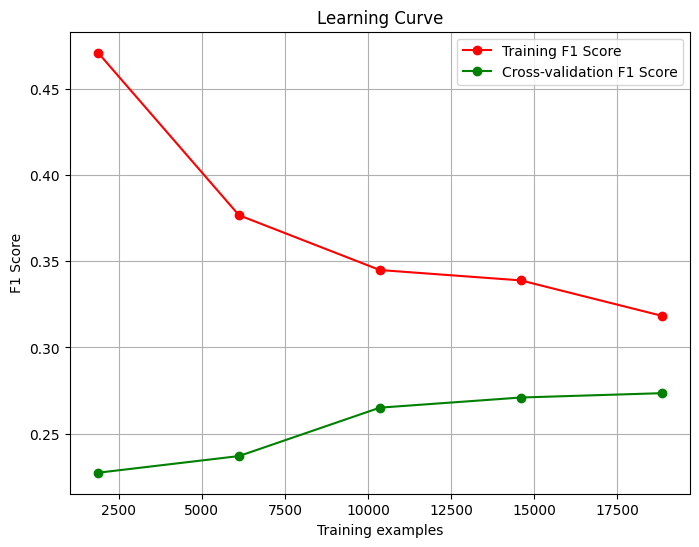

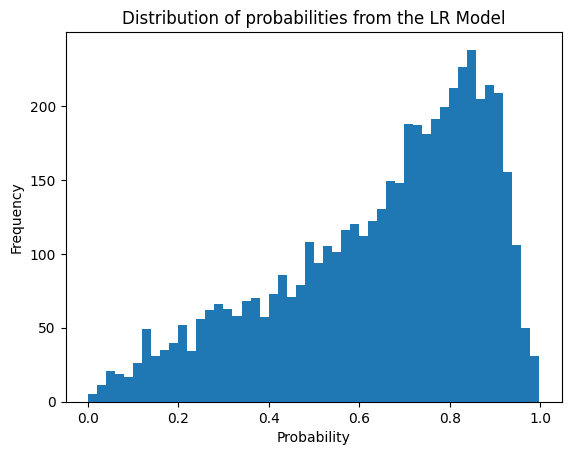

In [39]:
plot_learning_curve(lr_model, X_train_lr, y_train_lr)

# Histogram
plt.hist(prob, bins=50)
plt.title('Distribution of probabilities from the LR Model')
plt.xlabel('Probability')
plt.ylabel('Frequency')
plt.show()

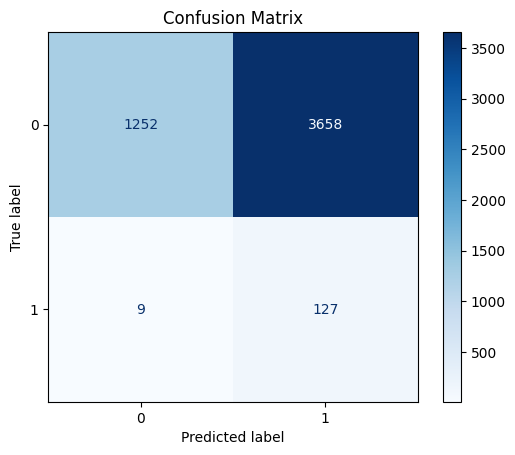

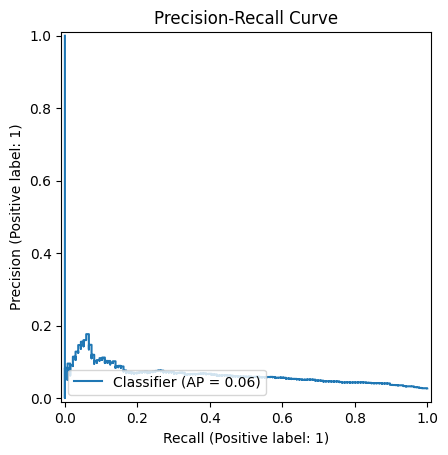

In [41]:
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import PrecisionRecallDisplay


# Using the predictions you already generated
ConfusionMatrixDisplay.from_predictions(y_val_lr, pred, cmap='Blues')
plt.title("Confusion Matrix")
plt.show()


PrecisionRecallDisplay.from_predictions(y_val_lr, prob)
plt.title("Precision-Recall Curve")
plt.show()

#### **Summary**
The LR Model was trained on the last timestep of each of the vehicle's readouts usint `class_weight = 'balanced'` to account for the severe class imbalance in the data set. The ratio between recall and precision as well as AUC ROC vs PR tells us that the model was able to gain some separability on the classes, but is far from stron. The distribution is concentrated around 0.5 which tells us it is a little better than randomly assigning the labels.

Furthermore, the aggressive class weighting also caused the model to flag nearly half of all vehicles as potential failures. It would probably be worse off overall if we did not include it, since false negatives are our biggest concern, however it indicates that the model is far from usable in rea industrial maintanance settings.

In conclusion, we have experienced expected behaviour from this model. THe Logisitic Regression is used only as a baseline model that is trained on the heavily imbalanced data set. The main goal here is to serve as a reference against LSTM / TCN but as well as data augmentation methods.

## 3.2 -  LSTM

### 3.2.1 -  Hyperparameters

In [27]:
HIDDEN_SIZE = 32
NUM_LAYERS = 1
LEARNING_RATE = 0.00001
BATCH_SIZE = 64
NUM_EPOCHS = 1000
PATIENCE = 15
DROPOUT = 0.5
CLIP_GRAD = 1.0

### 3.2.3 - Model Training

In [28]:
# Creating the Model
lstm = utils.LSTMModel(
    input_size=INPUT_SIZE,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT
)

# Creating the Trainer
lstm_trainer = utils.BaseTrainer(
    model=lstm,
    lr=LEARNING_RATE,
    batch_size=BATCH_SIZE,
    clip_grad=CLIP_GRAD
)

In [29]:
# Fitting on the training data and validating on the validation data, with early stopping and model checkpointing.
lstm_trainer.fit(
    X_train_seq, y_train_seq,
    X_val_seq, y_val_seq,
    num_epochs=NUM_EPOCHS,
    patience=PATIENCE,
    save_path=MODEL_DIR / 'lstm_model_best.pt'
);

Epoch 1/1000 - Time: 1.90s - Train: 0.0424 - Val: 0.0329 - Val AUC-PR: 0.0282
___________________________________
Epoch 2/1000 - Time: 1.70s - Train: 0.0401 - Val: 0.0306 - Val AUC-PR: 0.0295
___________________________________
Epoch 3/1000 - Time: 1.67s - Train: 0.0388 - Val: 0.0291 - Val AUC-PR: 0.0306
___________________________________
Epoch 4/1000 - Time: 1.71s - Train: 0.0380 - Val: 0.0280 - Val AUC-PR: 0.0315
___________________________________
Epoch 5/1000 - Time: 1.68s - Train: 0.0377 - Val: 0.0273 - Val AUC-PR: 0.0325
___________________________________
Epoch 6/1000 - Time: 1.64s - Train: 0.0374 - Val: 0.0268 - Val AUC-PR: 0.0335
___________________________________
Epoch 7/1000 - Time: 1.62s - Train: 0.0371 - Val: 0.0264 - Val AUC-PR: 0.0345
___________________________________
Epoch 8/1000 - Time: 1.62s - Train: 0.0371 - Val: 0.0261 - Val AUC-PR: 0.0357
___________________________________
Epoch 9/1000 - Time: 1.62s - Train: 0.0369 - Val: 0.0259 - Val AUC-PR: 0.0369
__________

c:\Users\Elias\Documents\SCANIA Component X\utils\trainer.py:183: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.model.load_state_dict(torch.load(save_path, map_location

### 3.2.4 -  Evaluation

___________________________________________
Standard Metrics:
Recall      : 0.4265
Precision   : 0.0503
F1          : 0.0901
AUC-ROC     : 0.6848
AUC-PR      : 0.0570


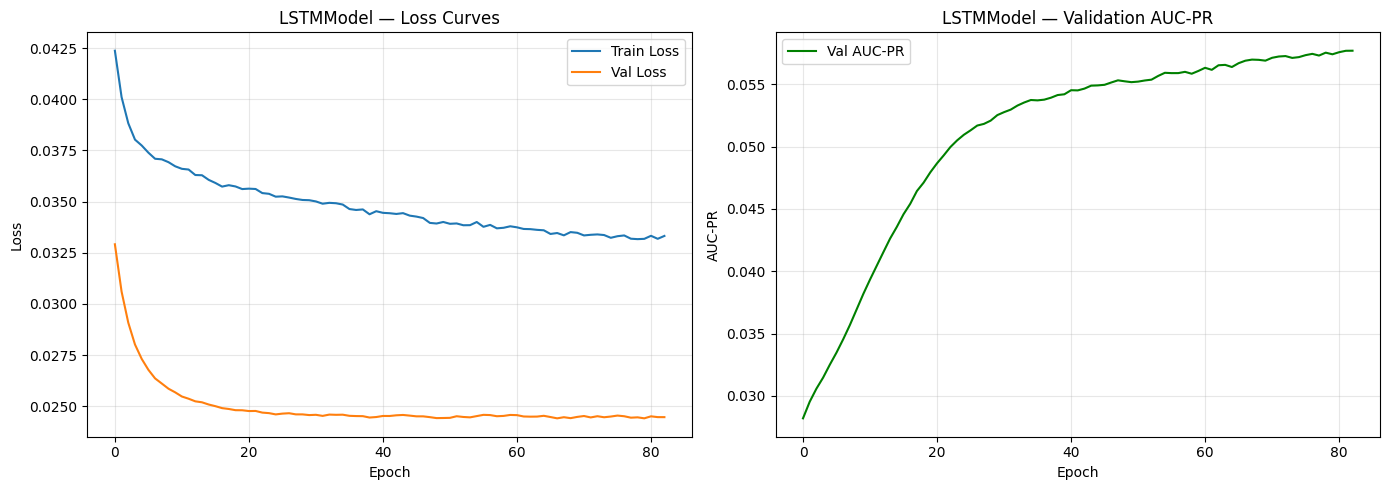

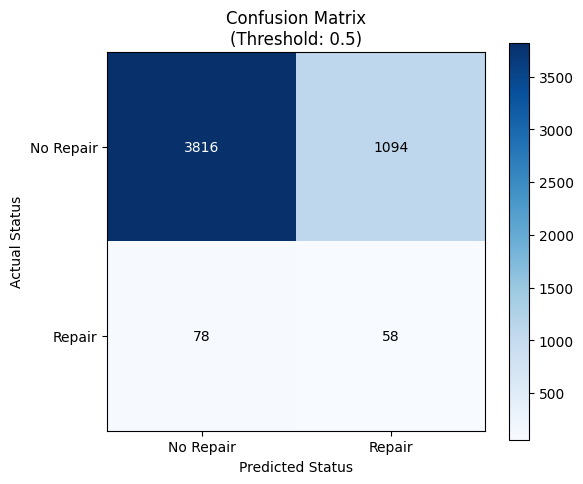

In [30]:
lstm_trainer.evaluate(X_val_seq, y_val_seq)
lstm_trainer.plot_history()
lstm_trainer.plot_cm(X_val_seq, y_val_seq)

In [31]:
import numpy as np
import pandas as pd


test_data   = pd.read_csv(DATA_DIR / 'test_processed.csv')

SCANIA_COST = {
    (0,0):0,   (0,1):7,   (0,2):8,   (0,3):9,   (0,4):10,
    (1,0):200, (1,1):0,   (1,2):7,   (1,3):8,   (1,4):9,
    (2,0):300, (2,1):200, (2,2):0,   (2,3):7,   (2,4):8,
    (3,0):400, (3,1):300, (3,2):200, (3,3):0,   (3,4):7,
    (4,0):500, (4,1):400, (4,2):300, (4,3):200, (4,4):0,
}

# VAL — tune
_, probs_val = lstm_trainer.predict(X_val_seq)
val_labels = pd.read_csv(PROJECT_ROOT / 'Data' / 'validation_labels.csv')
val_class = val_labels.set_index('vehicle_id').loc[val_seq_ids, 'class_label'].values

best_cost, best_t = float('inf'), 0.5
for t in np.arange(0.05, 0.95, 0.01):
    pred = (probs_val >= t).astype(int) * 4
    cost = sum(SCANIA_COST[(int(yt), int(yp))] for yt, yp in zip(val_class, pred))
    if cost < best_cost:
        best_cost, best_t = cost, t

print(f"VAL — best threshold: {best_t:.2f}")
print(f"VAL — cost per vehicle: {best_cost/len(val_class):.2f}")

# TEST — apply
X_test_seq, y_test_seq, test_seq_ids = utils.generate_sequential_data(test_data, 'label', SEQ_LEN)
_, probs_test = lstm_trainer.predict(X_test_seq)
test_labels = pd.read_csv(PROJECT_ROOT / 'Data' / 'test_labels.csv')
test_class = test_labels.set_index('vehicle_id').loc[test_seq_ids, 'class_label'].values

pred_test = (probs_test >= best_t).astype(int) * 4
cost_test = sum(SCANIA_COST[(int(yt), int(yp))] for yt, yp in zip(test_class, pred_test))

print(f"TEST — threshold: {best_t}")
print(f"TEST — cost per vehicle: {cost_test/len(test_class):.2f}")

VAL — best threshold: 0.46
VAL — cost per vehicle: 7.16
TEST — threshold: 0.4600000000000001
TEST — cost per vehicle: 7.84


## 3.3 - TCN

### 3.3.1 -  Hyperparameters

In [32]:
TCN_NUM_CHANNELS = 32
TCN_KERNEL_SIZE = 3
TCN_NUM_LAYERS = 2
TCN_LEARNING_RATE = 0.0001
TCN_BATCH_SIZE = 128
TCN_DROPOUT = 0.5
TCN_NUM_EPOCHS = 1000
TCN_PATIENCE = 10


### 3.3.2 -  Model Training

In [33]:
# Creating the TCN model
tcn = utils.TCNModel(
    input_size=INPUT_SIZE,
    num_channels=TCN_NUM_CHANNELS,
    num_layers=TCN_NUM_LAYERS,
    kernel_size=TCN_KERNEL_SIZE,
    dropout=TCN_DROPOUT
)

# Creating the TCN trainer
tcn_trainer = utils.BaseTrainer(
    model=tcn,
    lr=TCN_LEARNING_RATE,
    batch_size=TCN_BATCH_SIZE,
    clip_grad=None
)



In [34]:
# Fitting on the training data and validating on the validation data, with early stopping and model checkpointing.
tcn_trainer.fit(
    X_train_seq, y_train_seq,
    X_val_seq, y_val_seq,
    num_epochs=TCN_NUM_EPOCHS,
    patience=TCN_PATIENCE,
    save_path=MODEL_DIR / 'tcn_model_best.pt'
);

Epoch 1/1000 - Time: 15.54s - Train: 0.0795 - Val: 0.0410 - Val AUC-PR: 0.0301
___________________________________
Epoch 2/1000 - Time: 14.94s - Train: 0.0504 - Val: 0.0299 - Val AUC-PR: 0.0345
___________________________________
Epoch 3/1000 - Time: 15.23s - Train: 0.0445 - Val: 0.0271 - Val AUC-PR: 0.0399
___________________________________
Epoch 4/1000 - Time: 15.68s - Train: 0.0417 - Val: 0.0253 - Val AUC-PR: 0.0439
___________________________________
Epoch 5/1000 - Time: 15.34s - Train: 0.0400 - Val: 0.0247 - Val AUC-PR: 0.0474
___________________________________
Epoch 6/1000 - Time: 15.36s - Train: 0.0389 - Val: 0.0241 - Val AUC-PR: 0.0466
___________________________________
Epoch 7/1000 - Time: 15.56s - Train: 0.0371 - Val: 0.0238 - Val AUC-PR: 0.0502
___________________________________
Epoch 8/1000 - Time: 15.39s - Train: 0.0365 - Val: 0.0237 - Val AUC-PR: 0.0512
___________________________________
Epoch 9/1000 - Time: 15.33s - Train: 0.0358 - Val: 0.0244 - Val AUC-PR: 0.0519
_

c:\Users\Elias\Documents\SCANIA Component X\utils\trainer.py:183: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.model.load_state_dict(torch.load(save_path, map_location

### 3.3.3 -  Evaluation

___________________________________________
Standard Metrics:
Recall      : 0.5074
Precision   : 0.0471
F1          : 0.0862
AUC-ROC     : 0.6686
AUC-PR      : 0.0596


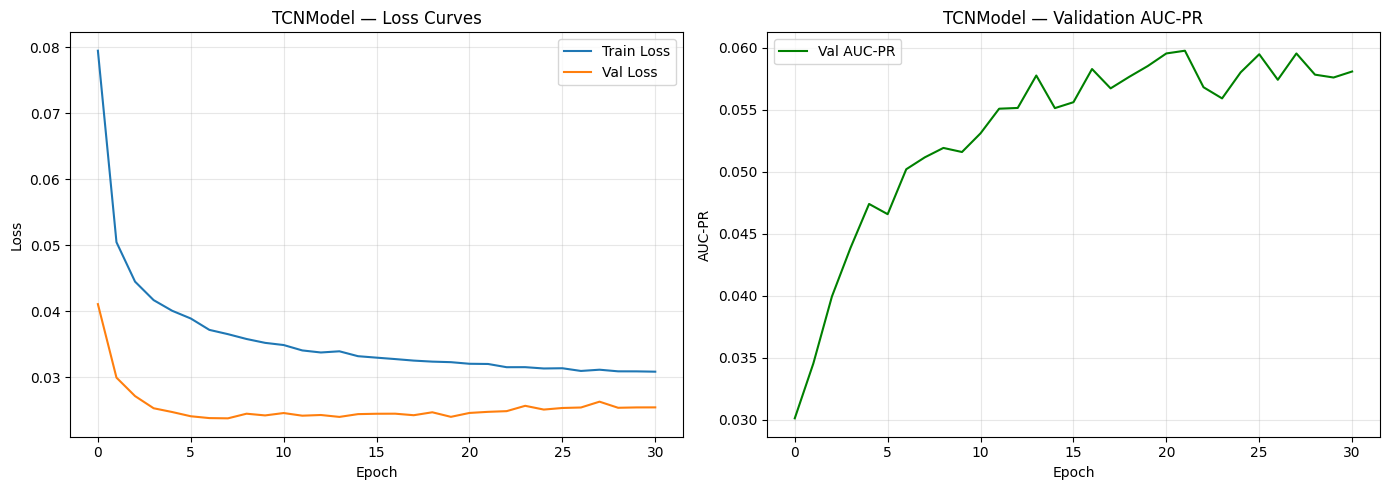

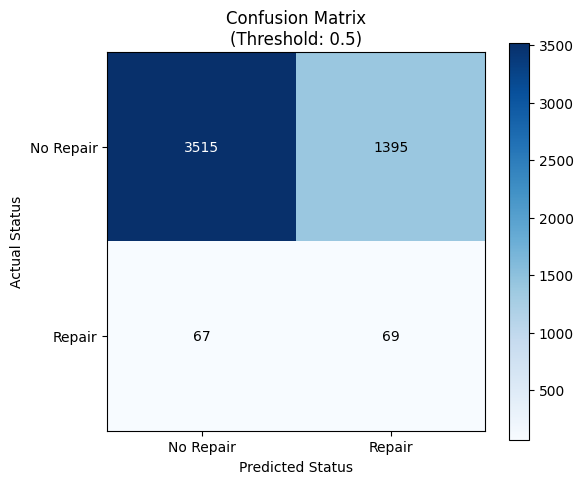

In [35]:
# Evaluating the TCN model on the validation set and plotting the results
tcn_trainer.evaluate(X_val_seq, y_val_seq)
tcn_trainer.plot_history()
tcn_trainer.plot_cm(X_val_seq, y_val_seq)

## 3.4  - Deep Learning Model Comparison

In [42]:
lstm_metrics, lstm_preds, lstm_probs = lstm_trainer.evaluate(X_val_seq, y_val_seq);
tcn_metrics, tcn_preds, tcn_probs = tcn_trainer.evaluate(X_val_seq, y_val_seq);

comparison = pd.DataFrame({
    'LR': lr_metrics,
    'LSTM': lstm_metrics,
    'TCN': tcn_metrics,
});
print(comparison.round(4))

___________________________________________
Standard Metrics:
Recall      : 0.4265
Precision   : 0.0503
F1          : 0.0901
AUC-ROC     : 0.6848
AUC-PR      : 0.0570
___________________________________________
Standard Metrics:
Recall      : 0.5074
Precision   : 0.0471
F1          : 0.0862
AUC-ROC     : 0.6686
AUC-PR      : 0.0596
               LR    LSTM     TCN
Recall     0.9338  0.4265  0.5074
Precision  0.0336  0.0503  0.0471
F1         0.0648  0.0901  0.0862
AUC-ROC    0.7160  0.6848  0.6686
AUC-PR     0.0645  0.0570  0.0596


# Section 4 - Data Augmentation

## 4.1 -  Encoder Training
The TapNet encoder requires its own validation signal for early stopping during representation learning. Using the project's validation set for this purpose would contaminate downstream evaluation, as the encoder's weights would be selected based on their fit to the same data later used to assess the SMOTE-augmented classifiers. We therefore carve a 15% slice from the training set as an encoder-internal validation set, keeping the project validation set unseen by the encoder until final evaluation.

In [43]:
import torch
import numpy as np

# Train the encoder briefly, just enough to learn useful representations
tapnet = utils.TapNetEncoder(input_size=INPUT_SIZE, embed_dim=64)
tapnet_trainer = utils.BaseTrainer(model=tapnet, lr=0.001, batch_size=64)
split = int(0.85 * len(X_train_seq))
tapnet_trainer.fit(X_train_seq[:split], y_train_seq[:split],
                   X_train_seq[split:], y_train_seq[split:],
                   num_epochs=30, patience=5, save_path=MODEL_DIR / 'tapnet_embed.pt');

# Extract embeddings in batches to avoid OOM
tapnet_trainer.model.eval()

def extract_embeddings_batched(model, X, batch_size=128):
    embeds = []
    with torch.no_grad():
        for i in range(0, len(X), batch_size):
            batch = torch.FloatTensor(X[i:i+batch_size]).to(DEVICE)
            emb = model.get_embedding(batch).cpu().numpy()
            embeds.append(emb)
            del batch
            torch.cuda.empty_cache()
    return np.concatenate(embeds, axis=0)

X_train_embedded = extract_embeddings_batched(tapnet_trainer.model, X_train_seq)
X_val_embedded   = extract_embeddings_batched(tapnet_trainer.model, X_val_seq)

# Validation that we did not get a wierd class balance
print(f"Train slice pos rate: {y_train_seq[:split].mean():.3f}")
print(f"Val slice pos rate:   {y_train_seq[split:].mean():.3f}")
print(f"Train embedded shape: {X_train_embedded.shape}")
print(f"Val embedded shape:   {X_val_embedded.shape}")

Epoch 1/30 - Time: 2.15s - Train: 0.0363 - Val: 0.0272 - Val AUC-PR: 0.0693
___________________________________
Epoch 2/30 - Time: 1.74s - Train: 0.0360 - Val: 0.0252 - Val AUC-PR: 0.0658
___________________________________
Epoch 3/30 - Time: 1.75s - Train: 0.0359 - Val: 0.0246 - Val AUC-PR: 0.0695
___________________________________
Epoch 4/30 - Time: 1.71s - Train: 0.0353 - Val: 0.0267 - Val AUC-PR: 0.0608
___________________________________
Epoch 5/30 - Time: 1.71s - Train: 0.0352 - Val: 0.0225 - Val AUC-PR: 0.0611
___________________________________
Epoch 6/30 - Time: 1.73s - Train: 0.0351 - Val: 0.0215 - Val AUC-PR: 0.0669
___________________________________
Early stopping at epoch: 6
Total elapsed time: 0 Minutes and 10.80 seconds
___________________________________


c:\Users\Elias\Documents\SCANIA Component X\utils\trainer.py:183: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.model.load_state_dict(torch.load(save_path, map_location

Train slice pos rate: 0.106
Val slice pos rate:   0.038
Train embedded shape: (23540, 64)
Val embedded shape:   (5046, 64)


## 4.2 -  Aplying the SMOTE Augmentation 



In [44]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=SEED)
X_resampled, y_resampled = smote.fit_resample(X_train_embedded, y_train_seq)

print(f"Before SMOTE: {X_train_embedded.shape} | Class balance: {dict(zip(*np.unique(y_train_seq, return_counts=True)))}")
print(f"After SMOTE:  {X_resampled.shape} | Class balance: {dict(zip(*np.unique(y_resampled, return_counts=True)))}")

Before SMOTE: (23540, 64) | Class balance: {np.int64(0): np.int64(21278), np.int64(1): np.int64(2262)}
After SMOTE:  (42556, 64) | Class balance: {np.int64(0): np.int64(21278), np.int64(1): np.int64(21278)}


## 4.3 -  Classification on Augmented Data

In [45]:
# --- Logistic Regression on SMOTE Embeddings ---
smote_lr = LogisticRegression(random_state=SEED, max_iter=1000)
smote_lr.fit(X_resampled, y_resampled)
smote_lr_pred = smote_lr.predict(X_val_embedded)
smote_lr_prob = smote_lr.predict_proba(X_val_embedded)[:, 1]

smote_lr_metrics = {
    'Recall': recall_score(y_val_seq, smote_lr_pred),
    'Precision': precision_score(y_val_seq, smote_lr_pred),
    'F1': f1_score(y_val_seq, smote_lr_pred),
    'AUC-ROC': roc_auc_score(y_val_seq, smote_lr_prob),
    'AUC-PR': average_precision_score(y_val_seq, smote_lr_prob),
}
print("SMOTE + LR:")
for k, v in smote_lr_metrics.items():
    print(f"  {k:12s}: {v:.4f}")

# --- XGBoost on SMOTE Embeddings ---
from xgboost import XGBClassifier
smote_xgb = XGBClassifier(random_state=SEED, n_estimators=100, max_depth=6, eval_metric='logloss')
smote_xgb.fit(X_resampled, y_resampled)
smote_xgb_pred = smote_xgb.predict(X_val_embedded)
smote_xgb_prob = smote_xgb.predict_proba(X_val_embedded)[:, 1]

smote_xgb_metrics = {
    'Recall': recall_score(y_val_seq, smote_xgb_pred),
    'Precision': precision_score(y_val_seq, smote_xgb_pred),
    'F1': f1_score(y_val_seq, smote_xgb_pred),
    'AUC-ROC': roc_auc_score(y_val_seq, smote_xgb_prob),
    'AUC-PR': average_precision_score(y_val_seq, smote_xgb_prob),
}
print("\nSMOTE + XGBoost:")
for k, v in smote_xgb_metrics.items():
    print(f"  {k:12s}: {v:.4f}")

SMOTE + LR:
  Recall      : 0.7941
  Precision   : 0.0346
  F1          : 0.0663
  AUC-ROC     : 0.6215
  AUC-PR      : 0.0395

SMOTE + XGBoost:
  Recall      : 0.4559
  Precision   : 0.0320
  F1          : 0.0598
  AUC-ROC     : 0.5742
  AUC-PR      : 0.0347


## 4.5 - Model Comparison

=== Comparison of all models===
               LR    LSTM     TCN  SMOTE+LR  SMOTE+XGB
Recall     0.9338  0.4265  0.5074    0.7941     0.4559
Precision  0.0336  0.0503  0.0471    0.0346     0.0320
F1         0.0648  0.0901  0.0862    0.0663     0.0598
AUC-ROC    0.7160  0.6848  0.6686    0.6215     0.5742
AUC-PR     0.0645  0.0570  0.0596    0.0395     0.0347


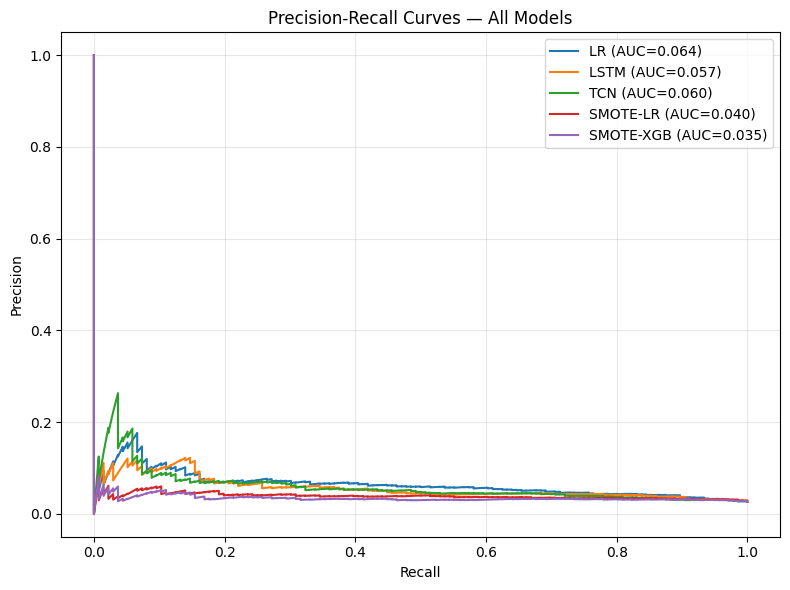

In [47]:
from sklearn.metrics import precision_recall_curve


# A quick check on model performance comparison
comparison_default = pd.DataFrame({
    'LR': lr_metrics,
    'LSTM': lstm_metrics,
    'TCN': tcn_metrics,
    'SMOTE+LR': smote_lr_metrics,
    'SMOTE+XGB': smote_xgb_metrics,
})
print("=== Comparison of all models===")
print(comparison_default.round(4))


plt.figure(figsize=(8, 6))

models = {
    'LR': (prob, y_val_lr),
    'LSTM': (lstm_probs, y_val_seq),
    'TCN': (tcn_probs, y_val_seq),
    'SMOTE-LR': (smote_lr_prob, y_val_seq),
    'SMOTE-XGB': (smote_xgb_prob, y_val_seq),
}

for name, (probs, y_true) in models.items():
    precision, recall, _ = precision_recall_curve(y_true, probs)
    auc = average_precision_score(y_true, probs)
    plt.plot(recall, precision, label=f'{name} (AUC={auc:.3f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves — All Models')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### Quick double check which model is best per kr

In [48]:
SCANIA_COST = {
    (0,0):0,   (0,1):7,   (0,2):8,   (0,3):9,   (0,4):10,
    (1,0):200, (1,1):0,   (1,2):7,   (1,3):8,   (1,4):9,
    (2,0):300, (2,1):200, (2,2):0,   (2,3):7,   (2,4):8,
    (3,0):400, (3,1):300, (3,2):200, (3,3):0,   (3,4):7,
    (4,0):500, (4,1):400, (4,2):300, (4,3):200, (4,4):0,
}

# Load test data and labels
test_data = pd.read_csv(DATA_DIR / 'test_processed.csv')
val_labels_full = pd.read_csv(PROJECT_ROOT / 'Data' / 'validation_labels.csv').set_index('vehicle_id')['class_label']
test_labels_full = pd.read_csv(PROJECT_ROOT / 'Data' / 'test_labels.csv').set_index('vehicle_id')['class_label']

# Build test inputs (same way val was built earlier in notebook)
X_test_lr, y_test_lr = utils.prepare_lr_data(test_data, 'label')
X_test_seq, y_test_seq, test_seq_ids = utils.generate_sequential_data(test_data, 'label', SEQ_LEN)

def cost_eval(probs_val, ids_val, probs_test, ids_test, name):
    val_y = val_labels_full.loc[ids_val].values
    test_y = test_labels_full.loc[ids_test].values
    
    best_cost, best_t = float('inf'), 0.5
    for t in np.arange(0.05, 0.95, 0.01):
        pred = (probs_val >= t).astype(int) * 4
        cost = sum(SCANIA_COST[(int(yt), int(yp))] for yt, yp in zip(val_y, pred))
        if cost < best_cost:
            best_cost, best_t = cost, t
    
    pred_test = (probs_test >= best_t).astype(int) * 4
    cost_test = sum(SCANIA_COST[(int(yt), int(yp))] for yt, yp in zip(test_y, pred_test))
    
    print(f"{name:6s}  threshold={best_t:.2f}  val_cost/veh={best_cost/len(val_y):.2f}  test_cost/veh={cost_test/len(test_y):.2f}")

# LR
_, lr_val_probs = get_lr_predictions(lr_model, X_val_lr)
_, lr_test_probs = get_lr_predictions(lr_model, X_test_lr)
cost_eval(lr_val_probs, X_val_lr.index.values, lr_test_probs, X_test_lr.index.values, "LR")

# LSTM
_, lstm_val_probs = lstm_trainer.predict(X_val_seq)
_, lstm_test_probs = lstm_trainer.predict(X_test_seq)
cost_eval(lstm_val_probs, val_seq_ids, lstm_test_probs, test_seq_ids, "LSTM")

# TCN
_, tcn_val_probs = tcn_trainer.predict(X_val_seq)
_, tcn_test_probs = tcn_trainer.predict(X_test_seq)
cost_eval(tcn_val_probs, val_seq_ids, tcn_test_probs, test_seq_ids, "TCN")

LR      threshold=0.70  val_cost/veh=6.72  test_cost/veh=8.81
LSTM    threshold=0.46  val_cost/veh=7.16  test_cost/veh=7.84
TCN     threshold=0.48  val_cost/veh=7.39  test_cost/veh=7.88


Model         Threshold   Val cost/veh   Test cost/veh
-------------------------------------------------------
LR                 0.70           6.72            8.81
LSTM               0.46           7.16            7.84
TCN                0.48           7.39            7.88
SMOTE+LR           0.44           8.24            8.06
SMOTE+XGB          0.16           8.59            9.17


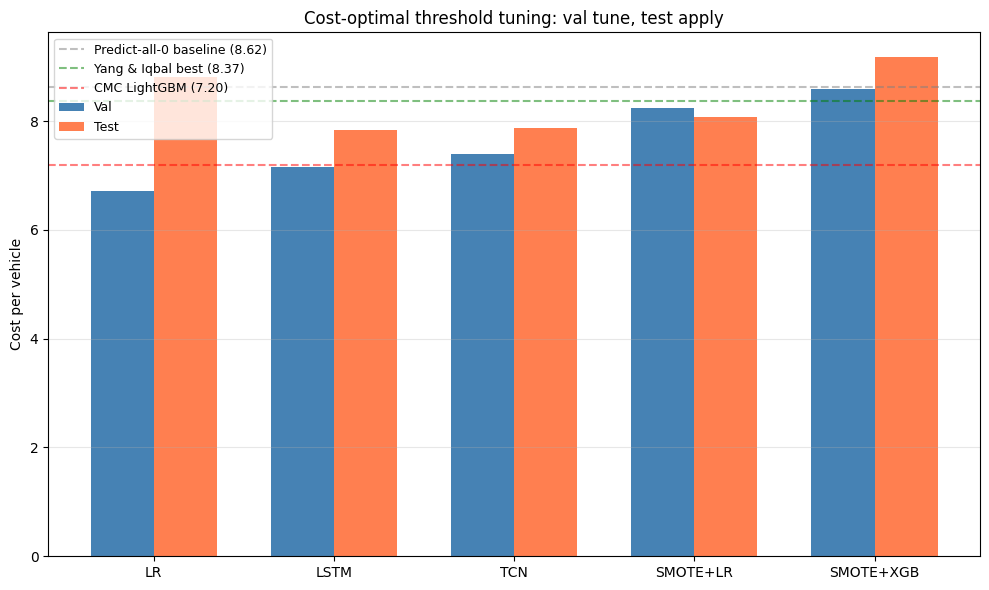

In [49]:

# Compute test embeddings using same TapNet model used to make X_val_embedded
X_test_embedded = extract_embeddings_batched(tapnet_trainer.model, X_test_seq)

def get_costs(probs_val, ids_val, probs_test, ids_test):
    val_y = val_labels_full.loc[ids_val].values
    test_y = test_labels_full.loc[ids_test].values
    
    best_cost, best_t = float('inf'), 0.5
    for t in np.arange(0.05, 0.95, 0.01):
        pred = (probs_val >= t).astype(int) * 4
        cost = sum(SCANIA_COST[(int(yt), int(yp))] for yt, yp in zip(val_y, pred))
        if cost < best_cost:
            best_cost, best_t = cost, t
    
    pred_test = (probs_test >= best_t).astype(int) * 4
    cost_test = sum(SCANIA_COST[(int(yt), int(yp))] for yt, yp in zip(test_y, pred_test))
    return best_t, best_cost/len(val_y), cost_test/len(test_y)

results = {}

# LR
_, p_v = get_lr_predictions(lr_model, X_val_lr)
_, p_t = get_lr_predictions(lr_model, X_test_lr)
results['LR'] = get_costs(p_v, X_val_lr.index.values, p_t, X_test_lr.index.values)

# LSTM
_, p_v = lstm_trainer.predict(X_val_seq)
_, p_t = lstm_trainer.predict(X_test_seq)
results['LSTM'] = get_costs(p_v, val_seq_ids, p_t, test_seq_ids)

# TCN
_, p_v = tcn_trainer.predict(X_val_seq)
_, p_t = tcn_trainer.predict(X_test_seq)
results['TCN'] = get_costs(p_v, val_seq_ids, p_t, test_seq_ids)

# SMOTE+LR
p_v = smote_lr.predict_proba(X_val_embedded)[:, 1]
p_t = smote_lr.predict_proba(X_test_embedded)[:, 1]
results['SMOTE+LR'] = get_costs(p_v, val_seq_ids, p_t, test_seq_ids)

# SMOTE+XGB
p_v = smote_xgb.predict_proba(X_val_embedded)[:, 1]
p_t = smote_xgb.predict_proba(X_test_embedded)[:, 1]
results['SMOTE+XGB'] = get_costs(p_v, val_seq_ids, p_t, test_seq_ids)

# Print table
print(f"{'Model':<12} {'Threshold':>10} {'Val cost/veh':>14} {'Test cost/veh':>15}")
print("-" * 55)
for name, (t, vc, tc) in results.items():
    print(f"{name:<12} {t:>10.2f} {vc:>14.2f} {tc:>15.2f}")

# Plot
names = list(results.keys())
val_costs = [results[n][1] for n in names]
test_costs = [results[n][2] for n in names]

x = np.arange(len(names))
w = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x - w/2, val_costs, w, label='Val', color='steelblue')
ax.bar(x + w/2, test_costs, w, label='Test', color='coral')

# Reference lines for published baselines
ax.axhline(8.62, color='gray', linestyle='--', alpha=0.5, label='Predict-all-0 baseline (8.62)')
ax.axhline(8.37, color='green', linestyle='--', alpha=0.5, label='Yang & Iqbal best (8.37)')
ax.axhline(7.20, color='red', linestyle='--', alpha=0.5, label='CMC LightGBM (7.20)')

ax.set_xticks(x)
ax.set_xticklabels(names)
ax.set_ylabel('Cost per vehicle')
ax.set_title('Cost-optimal threshold tuning: val tune, test apply')
ax.legend(loc='upper left', fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Section 5 Hyperparameter Tuning 

## 5.1 - Randomized Search on LSTM and TCN
These models were made with PyTorch, as such they do not follow Sklearn API meaning we need to do a manual random search. 

### 5.1.1 - LSTM 

In [ ]:
lstm_param_grid = {
    'hidden_size': [8, 16, 32, 64, 128],
    'num_layers':  [1, 2, 3],
    'dropout':     [0.1, 0.2, 0.3, 0.4, 0.5],
    'lr':          [0.00001, 0.0001, 0.0005, 0.001, 0.005, 0.01]
}

N_ITER_LSTM = 30


# LSTM
best_lstm_params, best_lstm_auc_pr, lstm_results = utils.random_search(
    model_class=utils.LSTMModel,
    param_grid=lstm_param_grid,
    model_kwargs_fn=lambda p: {
        'input_size':   INPUT_SIZE,
        'hidden_size':  p['hidden_size'],
        'num_layers':   p['num_layers'],
        'dropout':      p['dropout']
    },
    X_train=X_train_seq, y_train=y_train_seq,
    X_val=X_val_seq,     y_val=y_val_seq,
    n_iter=N_ITER_LSTM,
    num_epochs=NUM_EPOCHS,
    patience=PATIENCE,
    save_dir=MODEL_DIR,
    model_name='lstm',
    clip_grad=CLIP_GRAD
)


In [ ]:
# LSTM Search Results Plot
lstm_results_df = pd.DataFrame(lstm_results)

plt.figure(figsize=(10, 5))
plt.plot(lstm_results_df['trial'], lstm_results_df['auc_pr'], marker='o', color='darkorange')
plt.axhline(y=0.0644, color='red', linestyle='--', label='Baseline LSTM (0.0644)')
plt.xlabel('Trial')
plt.ylabel('AUC-PR')
plt.title('LSTM Random Search — AUC-PR per Trial')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Correlation analysis
print("\nLSTM Parameter Correlation with AUC-PR:")
print(lstm_results_df.corr()['auc_pr'].sort_values(ascending=False).round(4))

# Best LSTM retrained and evaluated on val
best_lstm = utils.LSTMModel(
    input_size=INPUT_SIZE,
    hidden_size=best_lstm_params['hidden_size'],
    num_layers=best_lstm_params['num_layers'],
    dropout=best_lstm_params['dropout']
)
best_lstm_trainer = utils.BaseTrainer(best_lstm, lr=best_lstm_params['lr'], clip_grad=CLIP_GRAD)
best_lstm_trainer.fit(
    X_train_seq, y_train_seq,
    X_val_seq, y_val_seq,
    num_epochs=NUM_EPOCHS,
    patience=PATIENCE,
    save_path=MODEL_DIR / 'lstm_best.pt'
)
lstm_metrics, lstm_preds, lstm_probs = best_lstm_trainer.evaluate(X_val_seq, y_val_seq)

### 5.1.2 - TCN

In [ ]:
tcn_param_grid = {
    'num_channels': [32, 64],        
    'num_layers':   [2, 3, 4],       
    'kernel_size':  [3, 5, 7],
    'dropout':      [0.1, 0.2, 0.3, 0.4, 0.5],
    'lr':           [0.00001, 0.0001, 0.0005, 0.001, 0.005, 0.01],
}

N_ITER_TCN = 10

# TCN
best_tcn_params, best_tcn_auc_pr, tcn_results = utils.random_search(
    model_class=utils.TCNModel,
    param_grid=tcn_param_grid,
    model_kwargs_fn=lambda p: {
        'input_size':   INPUT_SIZE,
        'num_channels': p['num_channels'],
        'num_layers':   p['num_layers'],
        'kernel_size':  p['kernel_size'],
        'dropout':      p['dropout']
    },
    X_train=X_train_seq, y_train=y_train_seq,
    X_val=X_val_seq,     y_val=y_val_seq,
    n_iter=N_ITER_TCN,
    num_epochs=NUM_EPOCHS,
    patience=PATIENCE,
    save_dir=MODEL_DIR,
    model_name='tcn',
    clip_grad=None
)

In [ ]:
# TCN Search Results Plot
tcn_results_df = pd.DataFrame(tcn_results)

plt.figure(figsize=(10, 5))
plt.plot(tcn_results_df['trial'], tcn_results_df['auc_pr'], marker='o', color='green')
plt.axhline(y=0.0596, color='red', linestyle='--', label='Baseline TCN (0.0596)')
plt.xlabel('Trial')
plt.ylabel('AUC-PR')
plt.title('TCN Random Search — AUC-PR per Trial')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Correlation analysis
print("\nTCN Parameter Correlation with AUC-PR:")
print(tcn_results_df.corr()['auc_pr'].sort_values(ascending=False).round(4))

# Best TCN retrained and evaluated on val
best_tcn = utils.TCNModel(
    input_size=INPUT_SIZE,
    num_channels=best_tcn_params['num_channels'],
    num_layers=best_tcn_params['num_layers'],
    kernel_size=best_tcn_params['kernel_size'],
    dropout=best_tcn_params['dropout']
)
best_tcn_trainer = utils.BaseTrainer(best_tcn, lr=best_tcn_params['lr'], clip_grad=None)
best_tcn_trainer.fit(
    X_train_seq, y_train_seq,
    X_val_seq, y_val_seq,
    num_epochs=NUM_EPOCHS,
    patience=PATIENCE,
    save_path=MODEL_DIR / 'tcn_best.pt'
)
tcn_metrics, tcn_preds, tcn_probs = best_tcn_trainer.evaluate(X_val_seq, y_val_seq)

## 5.2 - Randomized Search on XGBoost
XGBoost on the other hand, was made using Sklearn which means we can use the built in function `RandomizedSearchCV` instead.

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

xgb_param_grid = {
    'n_estimators': [50, 100, 200, 300],
    'max_depth':    [3, 4, 5, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample':    [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
}

xgb_search = RandomizedSearchCV(
    XGBClassifier(random_state=SEED, eval_metric='aucpr'),
    param_distributions=xgb_param_grid,
    n_iter=15,
    scoring='average_precision',
    cv=3,
    random_state=SEED,
    verbose=1
)
xgb_search.fit(X_resampled, y_resampled)
print(f"Best XGB params: {xgb_search.best_params_}")
print(f"Best XGB AUC-PR: {xgb_search.best_score_:.4f}")

In [ ]:
# Results DataFrame
xgb_results = pd.DataFrame(xgb_search.cv_results_)

# Plot 1 — AUC-PR per trial
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(xgb_results)+1), xgb_results['mean_test_score'], marker='o', color='steelblue')
plt.axhline(y=xgb_search.best_score_, color='red', linestyle='--', label=f'Best: {xgb_search.best_score_:.4f}')
plt.xlabel('Trial')
plt.ylabel('AUC-PR (CV mean)')
plt.title('XGBoost Random Search — AUC-PR per Trial')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Plot 2 — Parameter importance via correlation
params_df = pd.DataFrame(xgb_results['params'].tolist())
params_df['auc_pr'] = xgb_results['mean_test_score'].values
print("\nCorrelation with AUC-PR:")
print(params_df.corr()['auc_pr'].sort_values(ascending=False).round(4))

In [ ]:
best_xgb = XGBClassifier(
    random_state=SEED,
    eval_metric='aucpr',
    **xgb_search.best_params_
)
best_xgb.fit(X_resampled, y_resampled)
smote_xgb_pred = best_xgb.predict(X_val_embedded)
smote_xgb_prob = best_xgb.predict_proba(X_val_embedded)[:, 1]

smote_xgb_metrics = {
    'Recall': recall_score(y_val_seq, smote_xgb_pred),
    'Precision': precision_score(y_val_seq, smote_xgb_pred),
    'F1': f1_score(y_val_seq, smote_xgb_pred),
    'AUC-ROC': roc_auc_score(y_val_seq, smote_xgb_prob),
    'AUC-PR': average_precision_score(y_val_seq, smote_xgb_prob),
}
print("\nSMOTE + XGBoost:")
for k, v in smote_xgb_metrics.items():
    print(f"  {k:12s}: {v:.4f}")


## 5.X - Final Comparison

# Section 6 -  Final Model Training and Saving

## 5.1 -  Re-training the Models

### 5.1.1 - LSTM

In [ ]:
# Final LSTM Training with best hyperparameters
lstm = utils.LSTMModel(
    input_size=INPUT_SIZE,
    hidden_size=best_lstm_params['hidden_size'],
    num_layers=best_lstm_params['num_layers'],
    dropout=best_lstm_params['dropout']
)

lstm_trainer = utils.BaseTrainer(
    model=lstm,
    lr=best_lstm_params['lr'],
    batch_size=BATCH_SIZE,
    clip_grad=CLIP_GRAD
)

lstm_trainer.fit(
    X_train_seq, y_train_seq,
    X_val_seq, y_val_seq,
    num_epochs=NUM_EPOCHS,
    patience=PATIENCE,
    save_path=MODEL_DIR / 'lstm_best.pt'
)

In [ ]:
lstm_trainer.evaluate(X_val_seq, y_val_seq)
lstm_trainer.plot_history()
lstm_trainer.plot_cm(X_val_seq, y_val_seq)

### 5.1.2 - TCN

In [ ]:
# Final TCN Training with best hyperparameters
tcn = utils.TCNModel(
    input_size=INPUT_SIZE,
    num_channels=best_tcn_params['num_channels'],
    num_layers=best_tcn_params['num_layers'],
    kernel_size=best_tcn_params['kernel_size'],
    dropout=best_tcn_params['dropout']
)

tcn_trainer = utils.BaseTrainer(
    model=tcn,
    lr=best_tcn_params['lr'],
    batch_size=BATCH_SIZE,
    clip_grad=None
)


### 5.1.3 - XGBoost

### 5.1.4 - Final Comparison

## 5.2 - Saving Models, Data and Parameters

### 5.2.1 - Model Save

In [50]:
# Save baseline models
save_lr_model(lr_model, MODEL_DIR / 'lr_model.joblib')
save_lr_predictions(X_val_lr, pred, prob, PREDICTION_DIR / 'lr_val_predictions.csv')

# Save LSTM
lstm_trainer.save(
    val_data.groupby('vehicle_id').groups.keys(),
    X_val_seq, MODEL_DIR / 'lstm_best.pt',
    PREDICTION_DIR / 'lstm_val_predictions.csv'
)

# Save TCN
tcn_trainer.save(
    val_data.groupby('vehicle_id').groups.keys(),
    X_val_seq, MODEL_DIR / 'tcn_best.pt',
    PREDICTION_DIR / 'tcn_val_predictions.csv'
)

# Save SMOTE models
joblib.dump(smote_lr, MODEL_DIR / 'smote_lr_model.joblib')
joblib.dump(smote_xgb, MODEL_DIR / 'smote_xgb_model.joblib')

# Save TapNet encoder
torch.save(tapnet_trainer.model.state_dict(), MODEL_DIR / 'tapnet_encoder.pt')

# Saveing the SMOTE predictions CSV 
pd.DataFrame({
    'vehicle_id': list(val_data.groupby('vehicle_id').groups.keys()),
    'probability': smote_lr_prob,
    'binary_prediction': smote_lr_pred
}).to_csv(PREDICTION_DIR / 'smote_lr_val_predictions.csv', index=False)

pd.DataFrame({
    'vehicle_id': list(val_data.groupby('vehicle_id').groups.keys()),
    'probability': smote_xgb_prob,
    'binary_prediction': smote_xgb_pred
}).to_csv(PREDICTION_DIR / 'smote_xgb_val_predictions.csv', index=False)

print("All models saved.")


# Checking that the saved models have the same format
lr_preds = pd.read_csv(PREDICTION_DIR / 'lr_val_predictions.csv')
lstm_preds = pd.read_csv(PREDICTION_DIR / 'lstm_val_predictions.csv')
smote_lr_preds = pd.read_csv(PREDICTION_DIR / 'smote_lr_val_predictions.csv')
smote_xgb_preds = pd.read_csv(PREDICTION_DIR / 'smote_xgb_val_predictions.csv')

assert list(lr_preds['vehicle_id']) == list(lstm_preds['vehicle_id']), "LR vs LSTM mismatch"
assert list(lr_preds['vehicle_id']) == list(smote_lr_preds['vehicle_id']), "LR vs SMOTE-LR mismatch"
assert list(lr_preds['vehicle_id']) == list(smote_xgb_preds['vehicle_id']), "LR vs SMOTE-XGB mismatch"

print("All vehicle ID orders match! Models can be safely compared and ensembled.")

Saving the model...
Model saved to c:\Users\Elias\Documents\SCANIA Component X\Results\Models\lr_model.joblib
Saving the DataFrame...
DataFrame saved to c:\Users\Elias\Documents\SCANIA Component X\Results\Predictions\lr_val_predictions.csv
Model saved to c:\Users\Elias\Documents\SCANIA Component X\Results\Models\lstm_best.pt
Predictions saved to c:\Users\Elias\Documents\SCANIA Component X\Results\Predictions\lstm_val_predictions.csv
Model saved to c:\Users\Elias\Documents\SCANIA Component X\Results\Models\tcn_best.pt
Predictions saved to c:\Users\Elias\Documents\SCANIA Component X\Results\Predictions\tcn_val_predictions.csv
All models saved.
All vehicle ID orders match! Models can be safely compared and ensembled.


### 5.2.2 - Augmented Data Saving

In [52]:
# Save embeddings
np.save(PREDICTION_DIR / 'X_train_embedded.npy', X_train_embedded)
np.save(PREDICTION_DIR / 'X_val_embedded.npy', X_val_embedded)


# Save SMOTE augmented data
np.save(PREDICTION_DIR / 'X_resampled.npy', X_resampled)
np.save(PREDICTION_DIR / 'y_resampled.npy', y_resampled)

print("All embeddings and augmented data saved.")

All embeddings and augmented data saved.


### 5.2.3 -  Saving the HyperParameters

In [55]:
import json

hyperparams = {
    'INPUT_SIZE': INPUT_SIZE,
    'SEQ_LEN': SEQ_LEN,
    'LSTM': {
        'hidden_size': HIDDEN_SIZE,
        'num_layers': NUM_LAYERS,
        'dropout': DROPOUT,
        'learning_rate': LEARNING_RATE,
        'clip_grad': CLIP_GRAD,
    },
    'TCN': {
        'num_channels': TCN_NUM_CHANNELS,
        'num_layers': TCN_NUM_LAYERS,
        'kernel_size': TCN_KERNEL_SIZE,
        'dropout': TCN_DROPOUT,
        'learning_rate': TCN_LEARNING_RATE,
    }
}

with open(MODEL_DIR / 'hyperparams.json', 'w') as f:
    json.dump(hyperparams, f)
print("Hyperparameters saved.")

Hyperparameters saved.
